<a href="https://colab.research.google.com/github/sakethyalamanchili/SimpleML-Projects/blob/main/Predicting_Insurance_Charges_Using_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🔮 Predicting Insurance Charges Using Deep Learning.**

## **Introduction:**

In the ever-evolving field of machine learning and data science, predictive modeling plays a crucial role in many domains, particularly in industries like healthcare and insurance. This project aims to predict **insurance charges** based on various factors, such as age, sex, BMI, smoking status, and region, using a deep learning model.

The **insurance dataset** used in this project contains several attributes that can influence the insurance charges, with the primary goal being to build a regression model that can accurately predict the charges for individuals based on their characteristics.

### **Problem Statement:**

Insurance companies rely on predictive models to assess the risk of insuring individuals and determine appropriate premiums. This project uses a deep learning approach to predict insurance charges, which can aid insurance companies in streamlining the premium pricing process.

### **Dataset Overview:**

The dataset includes the following features:

* **Age**: The age of the individual.
* **Sex**: Gender of the individual.
* **BMI**: Body Mass Index.
* **Children**: The number of children/dependents covered by the insurance.
* **Smoker**: Whether or not the individual smokes.
* **Region**: The geographic region of the individual.
* **Charges**: The target variable, representing the insurance charges for the individual.

### **Objective:**

The main objective of this project is to:

1. Build a deep learning model to predict insurance charges.
2. Evaluate the model’s performance by comparing the predicted charges with the actual charges.
3. Visualize the true vs. predicted charges to assess how well the model has learned the underlying relationships in the data.

By applying deep learning techniques, we aim to develop a model that accurately predicts insurance charges, which could be useful for both insurers and customers alike in understanding and determining insurance premiums.

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## 2. Data Preprocessing

### Handle Categorical Variables

In [3]:
# Encode categorical variables
label_encoder = LabelEncoder()

data['sex'] = label_encoder.fit_transform(data['sex'])
data['smoker'] = label_encoder.fit_transform(data['smoker'])
data['region'] = label_encoder.fit_transform(data['region'])

# Check the changes
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### Handle Missing Values

In [4]:
# Check for missing values
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Feature and Target Split

In [5]:
X = data.drop('charges', axis=1)
y = data['charges']

### Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 6)
X_test shape: (268, 6)
y_train shape: (1070,)
y_test shape: (268,)


### Feature Scaling

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Building the Neural Network Model

In [8]:
# Create the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 13807.8867 - mae: 13807.8867 - val_loss: 12653.6172 - val_mae: 12653.6172
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13721.8242 - mae: 13721.8242 - val_loss: 12647.6553 - val_mae: 12647.6553
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13013.1699 - mae: 13013.1699 - val_loss: 12630.1982 - val_mae: 12630.1982
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13259.2295 - mae: 13259.2295 - val_loss: 12587.1318 - val_mae: 12587.1318
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13567.4043 - mae: 13567.4043 - val_loss: 12496.2969 - val_mae: 12496.2969
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12929.3633 - mae: 12929.3633 - val_loss: 12327.7178 - val_mae: 12327.7178
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12945.8887 - mae: 12945.8887 - val_loss: 12042.3037 - val_mae: 12042.3037
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12242.499

## 4. Evaluating the Model

In [9]:
# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=2)
print(f"Test MAE: {test_mae}")

# Make predictions
y_pred = model.predict(X_test)

# Calculate the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

9/9 - 0s - 6ms/step - loss: 2250.4026 - mae: 2250.4026
Test MAE: 2250.402587890625
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Mean Absolute Error (MAE): 2250.402392091214


## 5. Plotting the Training History

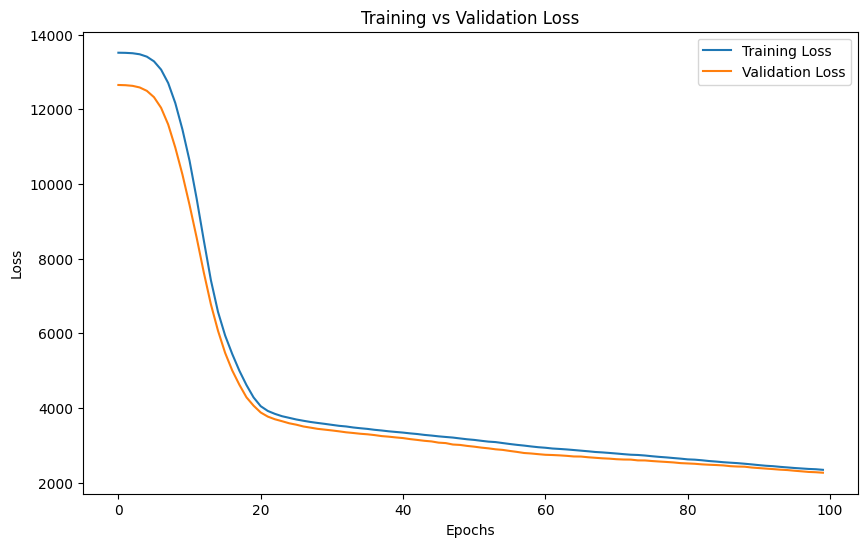

In [10]:
# Plot training history
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## 6. Prediction Visualization

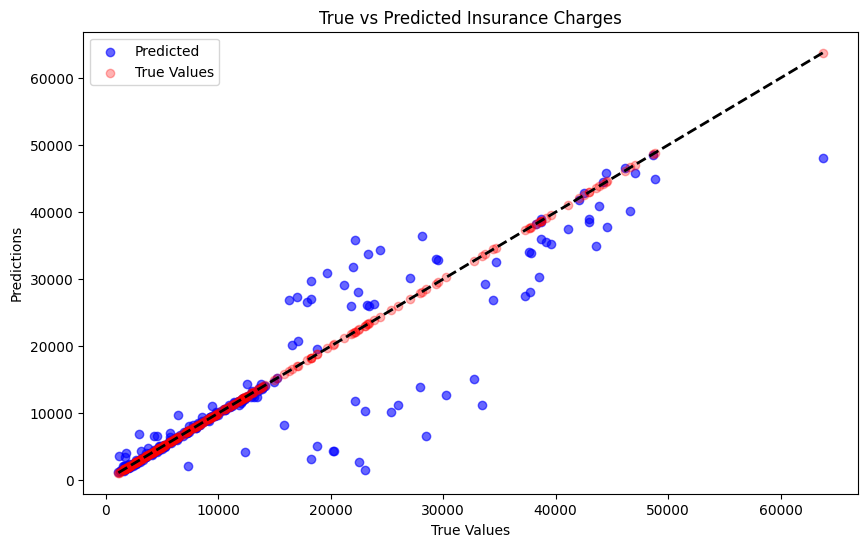

In [11]:
# Plot the true values and predictions with different colors
plt.figure(figsize=(10, 6))

# Scatter plot of true values in blue
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted', color='blue')

# Scatter plot of predicted values in red (overlayed)
plt.scatter(y_test, y_test, alpha=0.3, label='True Values', color='red')

# Plot the line of perfect prediction (45-degree line)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', lw=2)

# Add labels and title
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Insurance Charges')

# Add legend to differentiate between true values and predictions
plt.legend()

# Show the plot
plt.show()


## True vs Predicted Insurance Charges - Analysis

The scatter plot below compares the **true insurance charges** against the **predicted charges** from our regression model. In this plot:
- **Blue points** represent the predicted values.
- **Red points** represent the true values.
- The **black dashed line** represents the **line of perfect prediction**, where predicted values are equal to true values.

### Key Observations:

1. **Linear Relationship**:
   - The plot shows a clear positive linear relationship between the true and predicted values, which is ideal for a regression model. As the true values increase, the predicted values also increase.

2. **Clustering Around the Line**:
   - Most of the data points (both true and predicted) are clustered around the **black dashed line**, indicating that for most instances, the model is making accurate predictions.

3. **Outliers**:
   - Some points are further away from the line, indicating **outliers** where the model has struggled to predict the correct values. These points represent instances where the prediction error is more significant.

4. **Under-prediction at Higher Values**:
   - In the higher range of true values (i.e., when the insurance charges are high), the model tends to **under-predict**. This is evident from the **blue points** (predictions) that lie below the red points (true values) for higher charges.

### Interpretation:

- **Model Accuracy**: The model performs well overall, with most points close to the dashed line. However, there are some discrepancies, particularly in the higher true value range, where the model under-predicts.
  
- **Model Performance**: The spread of points around the line indicates that the model is doing a reasonable job but could be improved for instances with higher true values.

- **Potential Improvements**: The under-prediction at higher values suggests potential areas for improvement. This can be addressed by:
   - Adding more features.
   - Trying different model architectures (e.g., deeper layers or different activation functions).
   - Handling outliers and exploring feature transformations to better capture the variation in higher insurance charges.
